# 03 — Turnierfrequenz

Frage: *Spielen die beiden Gruppen gleich oft?*

Kennzahlen: `num_games` und `num_tournaments` pro (Spieler, Periode).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
from _setup import load_view, load_query, apply_style, GROUP_PALETTE, GROUP_ORDER

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

apply_style()

## Daten laden

In [2]:
df = load_view('v_tournament_frequency')
df['period'] = pd.to_datetime(df['period'])
print(df.shape)
df.head()

(17260, 5)


,analysis_group,fide_id,period,num_games,num_tournaments
0,female_top,617822,2015-05-01,6,1
1,female_top,617822,2015-07-01,11,1
2,female_top,617822,2015-12-01,8,1
3,female_top,617822,2016-07-01,4,1
4,female_top,617822,2017-06-01,15,2


## Summary pro Gruppe

In [3]:
df.groupby('analysis_group').agg(
    n_active_periods=('fide_id', 'count'),
    n_players=('fide_id', 'nunique'),
    mean_games_per_period=('num_games', 'mean'),
    median_games_per_period=('num_games', 'median'),
    mean_tournaments=('num_tournaments', 'mean'),
).round(2)

,n_active_periods,n_players,mean_games_per_period,median_games_per_period,mean_tournaments
analysis_group,,,,,
female_top,2882,43,9.71,9.0,1.32
male_control,14378,235,8.73,9.0,1.48


## Boxplot — Partien pro Periode

/var/folders/3b/wd_8tgyj0x3d8fgs9v_jsn1m0000gn/T/ipykernel_6576/3592950410.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


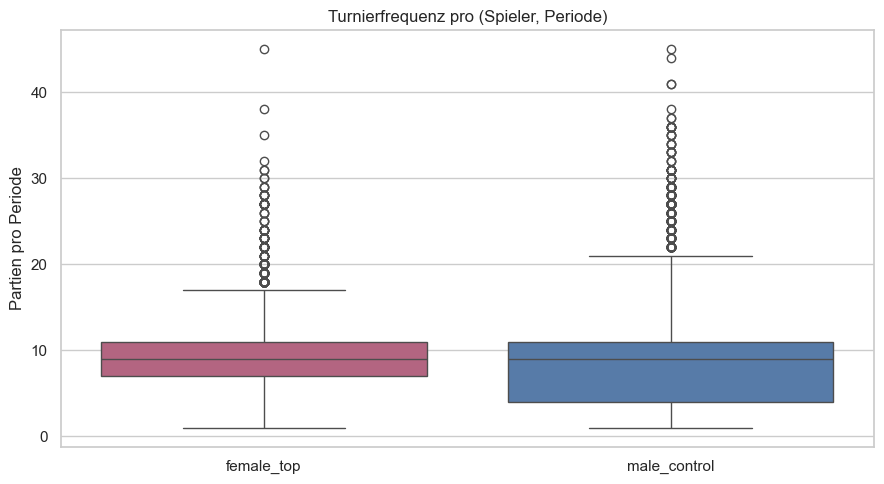

In [4]:
fig, ax = plt.subplots()
sns.boxplot(
    data=df, x='analysis_group', y='num_games',
    order=GROUP_ORDER, palette=GROUP_PALETTE, ax=ax,
)
ax.set_ylabel('Partien pro Periode')
ax.set_xlabel('')
ax.set_title('Turnierfrequenz pro (Spieler, Periode)')
plt.tight_layout(); plt.show()

## Saisonalität — Ø Partien pro Kalendermonat

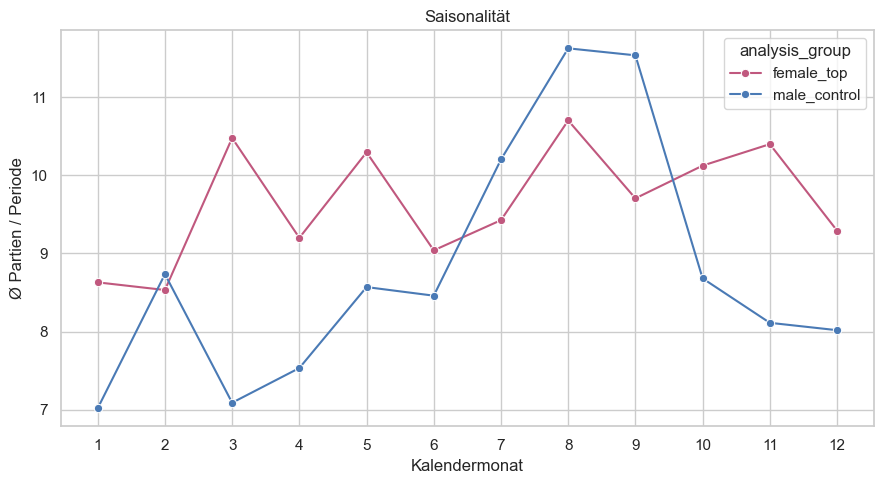

In [5]:
df['month'] = df['period'].dt.month
monthly = df.groupby(['analysis_group', 'month'])['num_games'].mean().reset_index()
fig, ax = plt.subplots()
sns.lineplot(
    data=monthly, x='month', y='num_games',
    hue='analysis_group', hue_order=GROUP_ORDER, palette=GROUP_PALETTE,
    marker='o', ax=ax,
)
ax.set_xticks(range(1, 13))
ax.set_xlabel('Kalendermonat')
ax.set_ylabel('Ø Partien / Periode')
ax.set_title('Saisonalität')
plt.tight_layout(); plt.show()